In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/Corn-leaf-disease-AI'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'Datasets/Corn')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'Models')
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'Results')
REPORTS_DIR  = os.path.join(PROJECT_ROOT, 'Reports')

# Sanity check
print(os.listdir(DATA_DIR))
# Should print: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [6]:
from tensorflow.keras import layers

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = train_ds.class_names
print(class_names)  # ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4188 files belonging to 4 classes.
Using 3351 files for training.
Found 4188 files belonging to 4 classes.
Using 837 files for validation.
['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

In [8]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,567 (16.08 MB)

 Trainable params: 164,740 (643.52 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model_phase1.keras'), save_best_only=True
    )
]

history1 = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 55s 330ms/step - accuracy: 0.8272 - auc: 0.9664 - loss: 0.4550 - precision: 0.8474 - recall: 0.8105 - val_accuracy: 0.9192 - val_auc: 0.9903 - val_loss: 0.2358 - val_precision: 0.9298 - val_recall: 0.9121 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8929 - auc: 0.9857 - loss: 0.2794 - precision: 0.9003 - recall: 0.8842 - val_accuracy: 0.9240 - val_auc: 0.9918 - val_loss: 0.2091 - val_precision: 0.9281 - val_recall: 0.9192 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.9057 - auc: 0.9890 - loss: 0.2450 - precision: 0.9135 - recall: 0.8985 - val_accuracy: 0.9145 - val_auc: 0.9931 - val_loss: 0.1926 - val_precision: 0.9231 - val_recall: 0.9121 - learning_rate: 0.0010
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.9150 - auc: 0.9910 - loss: 0.2188 - precision: 0.9238 - recall: 0.9078 - val_accuracy: 0.9216 - val_auc: 0.9935 - val_loss: 0.1

In [12]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)

callbacks2 = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model_final.keras'), save_best_only=True
    )
]

history2 = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks2)

Epoch 1/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 139ms/step - AUC: 0.9897 - accuracy: 0.9066 - loss: 0.2379 - val_AUC: 0.9912 - val_accuracy: 0.9169 - val_loss: 0.2246 - learning_rate: 1.0000e-05
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - AUC: 0.9897 - accuracy: 0.9102 - loss: 0.2306 - val_AUC: 0.9916 - val_accuracy: 0.9192 - val_loss: 0.2181 - learning_rate: 1.0000e-05
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - AUC: 0.9913 - accuracy: 0.9057 - loss: 0.2192 - val_AUC: 0.9920 - val_accuracy: 0.9192 - val_loss: 0.2126 - learning_rate: 1.0000e-05
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - AUC: 0.9907 - accuracy: 0.9245 - loss: 0.2185 - val_AUC: 0.9923 - val_accuracy: 0.9240 - val_loss: 0.2103 - learning_rate: 1.0000e-05
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - AUC: 0.9915 - accuracy: 0.9167 - loss: 0.2114 - val_AUC: 0.9926 - val_accuracy: 0.9264 - val_loss: 0.2060 - learning_rate: 1.0000e-05
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 1

In [13]:
# Check how many epochs it actually ran and best values
print("Epochs run:", len(history2.history['loss']))
print("Best val_accuracy:", max(history2.history['val_accuracy']))
print("Best val_loss:", min(history2.history['val_loss']))

Epochs run: 24
Best val_accuracy: 0.9382422566413879
Best val_loss: 0.16850526630878448


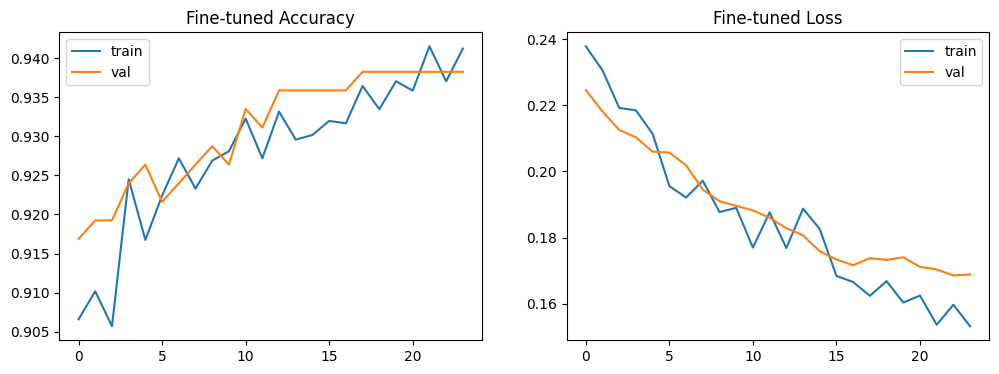

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
                precision    recall  f1-score   support

        Blight       0.84      0.94      0.89       112
   Common_Rust       1.00      0.96      0.98       129
Gray_Leaf_Spot       0.81      0.71      0.76        55
       Healthy       1.00      0.99      1.00       120

      accuracy                           0.93       416
     macro avg       0.91      0.90      0.90       416
  weighted avg       0.93      0.93      0.93       416



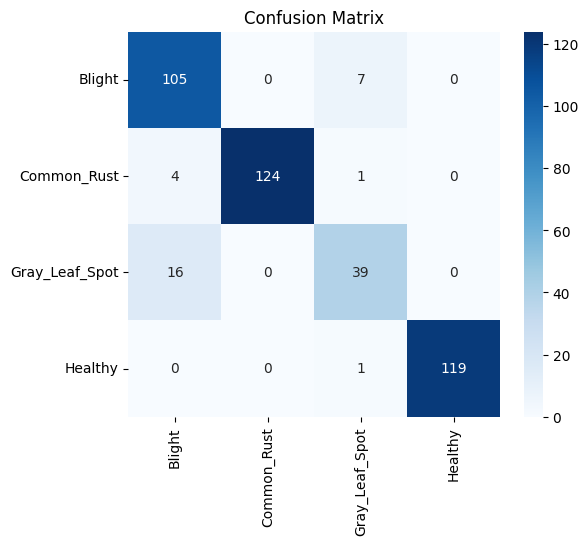

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def plot_history(h, title, save_name):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(h.history['accuracy']); plt.plot(h.history['val_accuracy']); plt.title(f'{title} Accuracy'); plt.legend(['train','val'])
    plt.subplot(1,2,2); plt.plot(h.history['loss']); plt.plot(h.history['val_loss']); plt.title(f'{title} Loss'); plt.legend(['train','val'])
    plt.savefig(os.path.join(RESULTS_DIR, save_name))
    plt.show()

plot_history(history2, "Fine-tuned", "training_curves.png")

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().argmax(axis=1))
    y_pred.extend(preds.argmax(axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save report to Reports/
with open(os.path.join(REPORTS_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()

In [15]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()[0]
# check last conv layer name via base_model.summary(), usually 'top_conv' for EfficientNetB0

In [16]:
model.save(os.path.join(MODELS_DIR, 'corn_disease_model.keras'))

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(os.path.join(MODELS_DIR, 'corn_model.tflite'), 'wb') as f:
    f.write(tflite_model)

print("All done. Model saved in:", MODELS_DIR)

Saved artifact at '/tmp/tmp_i9kurd4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139802396748752: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139802396751056: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139802425373712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425375248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425374864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425376016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425373520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425373328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425372944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139802425375632: TensorSpec(shape=(), dtype=tf.resource, name=

In [17]:
# Reload from the saved checkpoint to be 100% sure
model = tf.keras.models.load_model(
    os.path.join(MODELS_DIR, 'best_model_final.keras')
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
                precision    recall  f1-score   support

        Blight       0.84      0.94      0.89       112
   Common_Rust       1.00      0.96      0.98       129
Gray_Leaf_Spot       0.81      0.71      0.76        55
       Healthy       1.00      0.99      1.00       120

      accuracy                           0.93       416
     macro avg       0.91      0.90      0.90       416
  weighted avg       0.93      0.93      0.93       416



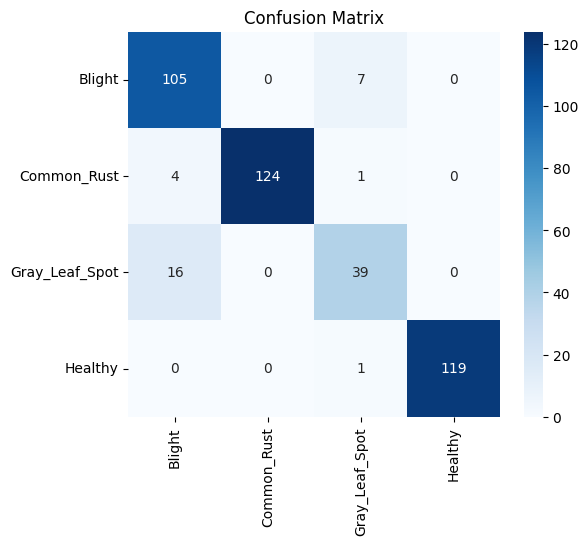

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().argmax(axis=1))
    y_pred.extend(preds.argmax(axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(os.path.join(REPORTS_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


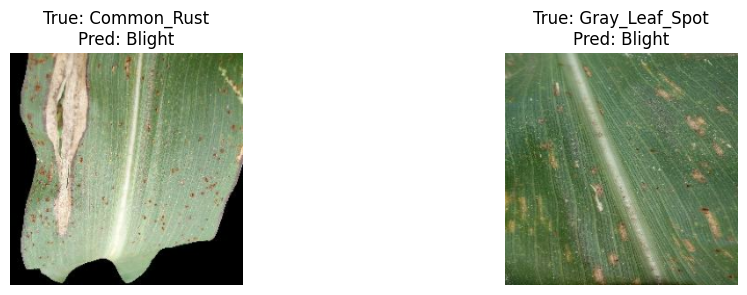

In [19]:
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_classes = preds.argmax(axis=1)
    true_classes = labels.numpy().argmax(axis=1)

    plt.figure(figsize=(15,8))
    shown = 0
    for i in range(len(images)):
        if true_classes[i] != pred_classes[i] and shown < 9:
            plt.subplot(3,3,shown+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}")
            plt.axis('off')
            shown += 1
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'misclassified_samples.png'))
    plt.show()

In [20]:
print(class_names)  # confirm index order, e.g. ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']

# Weight Gray_Leaf_Spot higher since it has lowest support (55) and lowest recall
class_weights = {0: 1.0, 1: 1.0, 2: 2.5, 3: 1.0}  # index 2 = Gray_Leaf_Spot — adjust if order differs

callbacks3 = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model_weighted.keras'), save_best_only=True
    )
]

history3 = model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    class_weight=class_weights, callbacks=callbacks3
)

['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 34s 145ms/step - AUC: 0.9949 - accuracy: 0.9388 - loss: 0.2466 - val_AUC: 0.9950 - val_accuracy: 0.9406 - val_loss: 0.1649 - learning_rate: 3.0000e-06
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - AUC: 0.9952 - accuracy: 0.9403 - loss: 0.2448 - val_AUC: 0.9952 - val_accuracy: 0.9454 - val_loss: 0.1621 - learning_rate: 3.0000e-06
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - AUC: 0.9946 - accuracy: 0.9376 - loss: 0.2473 - val_AUC: 0.9952 - val_accuracy: 0.9430 - val_loss: 0.1614 - learning_rate: 3.0000e-06
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - AUC: 0.9950 - accuracy: 0.9403 - loss: 0.2342 - val_AUC: 0.9952 - val_accuracy: 0.9430 - val_loss: 0.1605 - learning_rate: 3.0000e-06
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - AUC: 0.9950 - accuracy: 0.9361 - loss: 0.2362 - val_AUC: 0.9953 - val_accuracy: 0.9430 - val_loss: 0.1589 - learning_rate: 3

In [21]:
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy().argmax(axis=1))
    y_pred.extend(preds.argmax(axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
                precision    recall  f1-score   support

        Blight       0.85      0.94      0.89       112
   Common_Rust       1.00      0.96      0.98       129
Gray_Leaf_Spot       0.83      0.73      0.78        55
       Healthy       1.00      1.00      1.00       120

      accuracy                           0.94       416
     macro avg       0.92      0.91      0.91       416
  weighted avg       0.94      0.94      0.93       416



In [22]:
# Confirm this is your final model
import shutil
shutil.copy(
    os.path.join(MODELS_DIR, 'best_model_weighted.keras'),
    os.path.join(MODELS_DIR, 'corn_disease_model_FINAL.keras')
)
print("Final model saved.")

Final model saved.


In [23]:
# Check last conv layer name first
for layer in base_model.layers[-5:]:
    print(layer.name)

block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [24]:
import os
print(os.listdir(MODELS_DIR))
# Should show: best_model_phase1.keras, best_model_final.keras, corn_disease_model.keras, corn_model.tflite (if exported)

['best_model_phase1.keras', 'best_model_final.keras', 'corn_disease_model.keras', 'corn_model.tflite', 'best_model_weighted.keras', 'corn_disease_model_FINAL.keras']


In [28]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    base_model = model.get_layer('efficientnetb0')

    # Build a clean model: base_model input -> conv layer output only
    grad_model_base = tf.keras.models.Model(base_model.input, base_model.get_layer(last_conv_layer_name).output)

    # Preprocess manually (data augmentation is a no-op at inference, so we skip it)
    preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array)

    with tf.GradientTape() as tape:
        conv_outputs = grad_model_base(preprocessed)
        tape.watch(conv_outputs)

        # Manually replay the head layers from your model summary
        x = model.get_layer('global_average_pooling2d')(conv_outputs)
        x = model.get_layer('dropout')(x, training=False)
        x = model.get_layer('dense')(x)
        x = model.get_layer('batch_normalization')(x, training=False)
        x = model.get_layer('dropout_1')(x, training=False)
        predictions = model.get_layer('dense_1')(x)

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()[0]

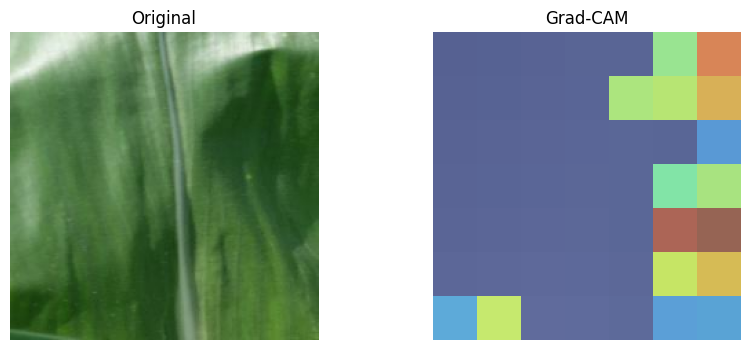

In [29]:
for images, labels in test_ds.take(1):
    img = images[0:1]
    heatmap = make_gradcam_heatmap(img, model)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img[0].numpy().astype("uint8")); plt.title("Original"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img[0].numpy().astype("uint8")); plt.imshow(heatmap, cmap='jet', alpha=0.5); plt.title("Grad-CAM"); plt.axis('off')
    plt.savefig(os.path.join(RESULTS_DIR, 'gradcam_example.png'))
    plt.show()
    break